# Average Shortest Paths Notebook

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from ts2vg import HorizontalVG, NaturalVG

In [9]:
data = pd.read_csv('./data/stock_data_with_sectors.csv')
data['Date'] = data['Date'].astype('datetime64[s]')
data = data.dropna(subset='Close').reset_index(drop=True)

In [10]:
with open("./data/tickers.txt", "r") as f:
    tickers = [line.strip() for line in f if line.strip()]

In [11]:
data

,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Sector,Industry
0,2001-06-04,0.376429,0.376964,0.365357,0.368929,0.309233,281920800.0,AAPL,Technology,Consumer Electronics
1,2001-06-05,0.371429,0.376786,0.363393,0.373929,0.313424,471794400.0,AAPL,Technology,Consumer Electronics
2,2001-06-06,0.373750,0.373750,0.363036,0.370179,0.310281,223176800.0,AAPL,Technology,Consumer Electronics
3,2001-06-07,0.369821,0.387500,0.365179,0.386786,0.324201,325180800.0,AAPL,Technology,Consumer Electronics
4,2001-06-08,0.386607,0.386607,0.369821,0.380714,0.319111,342624800.0,AAPL,Technology,Consumer Electronics
...,...,...,...,...,...,...,...,...,...,...
590947,2026-05-26,80.779999,81.309998,79.949997,80.230003,80.230003,5696600.0,ZTS,Healthcare,Drug Manufacturers - Specialty & Generic
590948,2026-05-27,80.019997,81.139999,78.730003,79.480003,79.480003,7874000.0,ZTS,Healthcare,Drug Manufacturers - Specialty & Generic
590949,2026-05-28,79.000000,80.199997,78.250000,78.269997,78.269997,7686200.0,ZTS,Healthcare,Drug Manufacturers - Specialty & Generic
590950,2026-05-29,78.510002,78.879997,77.440002,77.690002,77.690002,9295100.0,ZTS,Healthcare,Drug Manufacturers - Specialty & Generic


In [4]:
TICKER = 'AAPL'

In [5]:
### avsp ==> Average Shortest Path
def ts2vg_shortest_path_features(arr, lookback):
    avsp_p = np.zeros(len(arr))
    avsp_n = np.zeros(len(arr))

    avsp_p[:] = np.nan
    avsp_n[:] = np.nan

    for i in range(lookback, len(arr)):
        dat = arr[i - lookback + 1: i+1]

        pos = NaturalVG()
        pos.build(dat)

        neg = NaturalVG()
        neg.build(-dat)

        neg = neg.as_networkx()
        pos = pos.as_networkx()
        
        avsp_p[i] = nx.average_shortest_path_length(pos)
        avsp_n[i] = nx.average_shortest_path_length(neg)

    return avsp_p, avsp_n

In [6]:
df = data[data["Ticker"] == TICKER].copy()
### Subset for initial testing
df = df.iloc[:200, :]
df = df.sort_values("Date").set_index("Date")

In [7]:
lookback = 7
arr = df["Close"].to_numpy()

### Get shortest path features
pos, neg = ts2vg_shortest_path_features(arr, lookback)

df["pos"] = pos
df["neg"] = neg
df = df.dropna().reset_index()

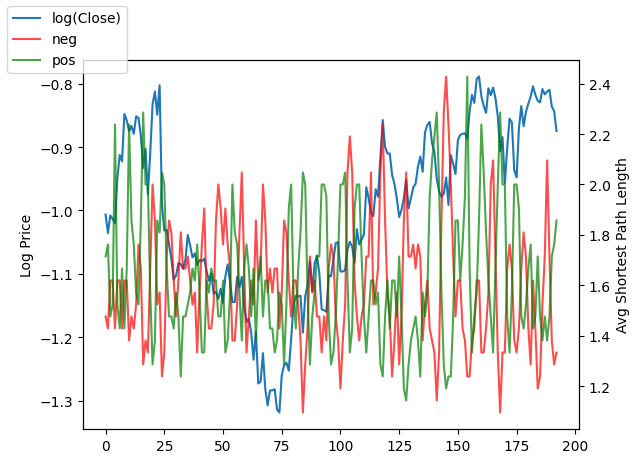

In [8]:
fig, ax1 = plt.subplots()

ax1.plot(np.log(df["Close"]), label="log(Close)")
ax1.set_ylabel("Log Price")

ax2 = ax1.twinx()
ax2.plot(df["neg"], color="red", label="neg", alpha=0.7)
ax2.plot(df["pos"], color="green", label="pos", alpha=0.7)
ax2.set_ylabel("Avg Shortest Path Length")

fig.legend(loc="upper left")
plt.show()

In [9]:
def get_avsp_one_stock(ticker, data=data, lookback=7, num_col='Close', ret_cols = ['Date', 'Ticker', 'Sector', 'Industry', 'pos', 'neg']):
    df = data[data["Ticker"] == ticker].copy()
    df = df.sort_values("Date").set_index("Date")
    arr = df[num_col].to_numpy()

    ### Get shortest path features
    pos, neg = ts2vg_shortest_path_features(arr, lookback)

    df["pos"] = pos
    df["neg"] = neg
    df = df.dropna().reset_index()
    
    cols = ret_cols + [num_col]

    return df[cols]

In [ ]:
def get_all_avsp(tickers=tickers, data=data, lookback=7, num_col='Close', ret_cols = ['Date', 'Ticker', 'Sector', 'Industry', 'pos', 'neg']):
    all_avsp = pd.DataFrame()
    
    for t in tickers:
        avsp_df = get_avsp_one_stock(ticker=t, data=data, lookback=lookback, num_col=num_col, ret_cols=ret_cols)
        
        if len(all_avsp) == 0:
            all_avsp = avsp_df.copy()
        else:
            all_avsp = pd.concat([all_avsp, avsp_df])
    
    return all_avsp

In [ ]:
lookback=7
all_avsp = get_all_avsp(tickers=tickers, lookback=7)
all_avsp.to_csv(f"./data/all_avsp_window_{lookback}.csv", index=False)